# Attention-head outputs in character-count probe PCA space

This notebook fits the same multinomial character-count probes used in Notebook 6, builds a 2D or 3D PCA basis from the centered probe directions, and projects attention-head outputs into that basis.

A head output is its residual-stream contribution `z @ W_O`, with shape `d_model`. For every layer and positive character count, the notebook averages this contribution separately for each head. It also computes the sum of the per-head averages. The sum excludes the shared attention output bias, so it is exactly the sum of the plotted head contributions.

In [22]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
PROBE_ACTIVATION_SITE = "blocks.2.hook_resid_pre"

# Set to either 2 or 3.
PCA_DIMENSIONS = 3
N_PROBE_TRAIN_SEQUENCES = 2_000
N_HEAD_OUTPUT_SEQUENCES = 5_000
COLLECTION_BATCH_SIZE = 128
PROBE_TRAIN_SEED = 17_290
HEAD_OUTPUT_SEED = 90_901
ANNOTATE_EVERY = 10

# Camera angles rendered for every layer when PCA_DIMENSIONS == 3.
# Each tuple is (elevation, azimuth) in degrees.
THREE_D_VIEW_ANGLES = [
    (20, -60),
    (20, 0),
    (20, 60),
    (60, -60),
]


In [23]:
if PCA_DIMENSIONS not in (2, 3):
    raise ValueError("PCA_DIMENSIONS must be 2 or 3.")

with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

_, max_line_length = project_data.get_line_length_range(cfg["task"])
max_character_count = max_line_length + cfg["task"]["num_token_lengths"] - 1
CHARACTER_COUNTS = np.arange(1, max_character_count + 1)
N_CHARACTER_COUNTS = len(CHARACTER_COUNTS)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH,
    model=model,
    map_location=device,
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
d_model = cfg["model"]["d_model"]

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Model: {n_layers} layers, {n_heads} heads, d_model={d_model}")
print(f"Probe PCA dimensions: {PCA_DIMENSIONS}")


Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Model: 3 layers, 4 heads, d_model=128
Probe PCA dimensions: 3


## Reproduce the character-count probes from Notebook 6

Counts are aligned with input-token residual positions. Count 0 is excluded because it combines BOS and newline positions.

In [24]:
def character_counts_for_tokens(token_rows: torch.Tensor) -> torch.Tensor:
    """Return the running character count at every input-token position."""
    all_counts = []

    for token_row in token_rows.detach().cpu().tolist():
        running_count = 0
        row_counts = []

        for token_id in token_row:
            if token_id == vocab.newline_id:
                running_count = 0
            else:
                running_count += project_data.extract_character_count(
                    vocab.decode_token(token_id)
                )
            row_counts.append(running_count)

        all_counts.append(row_counts)

    return torch.tensor(all_counts, dtype=torch.long)


@torch.no_grad()
def collect_probe_training_data(
    n_sequences: int,
    *,
    batch_size: int = COLLECTION_BATCH_SIZE,
    seed: int = PROBE_TRAIN_SEED,
) -> tuple[np.ndarray, np.ndarray]:
    activation_chunks = []
    count_chunks = []

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )
        counts = character_counts_for_tokens(batch.tokens)
        saved = {}

        def save_residuals(activation, hook):
            saved["residuals"] = activation.detach().cpu()

        model.run_with_hooks(
            batch.tokens,
            prepend_bos=False,
            fwd_hooks=[(PROBE_ACTIVATION_SITE, save_residuals)],
        )

        keep = counts > 0
        activation_chunks.append(saved["residuals"][keep].float().numpy())
        count_chunks.append(counts[keep].numpy())

    return np.concatenate(activation_chunks), np.concatenate(count_chunks)


In [25]:
X_probe_train, y_probe_train = collect_probe_training_data(
    N_PROBE_TRAIN_SEQUENCES
)

missing_probe_counts = sorted(
    set(CHARACTER_COUNTS) - set(np.unique(y_probe_train))
)
if missing_probe_counts:
    raise RuntimeError(
        f"Probe training data is missing counts {missing_probe_counts}. "
        "Increase N_PROBE_TRAIN_SEQUENCES."
    )

probe_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=1_000,
        tol=1e-3,
    ),
)
probe_model.fit(X_probe_train, y_probe_train)

standardizer = probe_model.named_steps["standardscaler"]
logistic_regression = probe_model.named_steps["logisticregression"]
if not np.array_equal(logistic_regression.classes_, CHARACTER_COUNTS):
    raise RuntimeError("Probe classes do not match CHARACTER_COUNTS.")

# Convert coefficients back to residual-stream coordinates, then remove
# the multinomial classifier's shared-vector degree of freedom.
probe_vectors = logistic_regression.coef_ / standardizer.scale_[None, :]
centered_probe_vectors = probe_vectors - probe_vectors.mean(axis=0, keepdims=True)

probe_pca = PCA(n_components=PCA_DIMENSIONS)
projected_probe_vectors = probe_pca.fit_transform(centered_probe_vectors)

print("Probe training data:", X_probe_train.shape)
print("Probe vectors:", centered_probe_vectors.shape)
print("PCA explained variance ratio:", probe_pca.explained_variance_ratio_)


Probe training data: (281926, 128)
Probe vectors: (107, 128)
PCA explained variance ratio: [0.54146169 0.24308803 0.09800644]


## Average each head's residual contribution by character count

TransformerLens `hook_z` has shape `[batch, position, head, d_head]`. Multiplying each head by its own `W_O` produces one `[d_model]` residual contribution per token.

In [26]:
@torch.no_grad()
def collect_mean_head_outputs_by_count(
    n_sequences: int,
    *,
    batch_size: int = COLLECTION_BATCH_SIZE,
    seed: int = HEAD_OUTPUT_SEED,
) -> tuple[np.ndarray, np.ndarray]:
    output_sums = torch.zeros(
        n_layers,
        N_CHARACTER_COUNTS,
        n_heads,
        d_model,
        dtype=torch.float64,
    )
    examples_per_count = torch.zeros(N_CHARACTER_COUNTS, dtype=torch.long)
    z_names = [f"blocks.{layer}.attn.hook_z" for layer in range(n_layers)]

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )
        counts = character_counts_for_tokens(batch.tokens)
        keep = counts > 0
        count_indices = counts[keep] - 1

        _, cache = model.run_with_cache(
            batch.tokens,
            prepend_bos=False,
            names_filter=lambda name: name in z_names,
        )

        examples_per_count.index_add_(
            0,
            count_indices,
            torch.ones_like(count_indices),
        )

        for layer, z_name in enumerate(z_names):
            z = cache[z_name]
            # [batch, position, head, d_head] @ [head, d_head, d_model]
            # -> [batch, position, head, d_model]
            head_outputs = torch.einsum(
                "bphd,hdm->bphm",
                z,
                model.W_O[layer],
            )
            selected_outputs = head_outputs.detach().cpu()[keep].double()
            output_sums[layer].index_add_(
                0,
                count_indices,
                selected_outputs,
            )

    if torch.any(examples_per_count == 0):
        missing = CHARACTER_COUNTS[examples_per_count.numpy() == 0].tolist()
        raise RuntimeError(
            f"Head-output data is missing counts {missing}. "
            "Increase N_HEAD_OUTPUT_SEQUENCES."
        )

    mean_outputs = output_sums / examples_per_count[None, :, None, None]
    return mean_outputs.numpy(), examples_per_count.numpy()


mean_head_outputs, examples_per_count = collect_mean_head_outputs_by_count(
    N_HEAD_OUTPUT_SEQUENCES
)
mean_summed_head_output = mean_head_outputs.sum(axis=2)

print("Mean per-head outputs:", mean_head_outputs.shape)
print("Mean summed outputs:", mean_summed_head_output.shape)
print("Examples per count:", examples_per_count.min(), "to", examples_per_count.max())


Mean per-head outputs: (3, 107, 4, 128)
Mean summed outputs: (3, 107, 128)
Examples per count: 12 to 12889


In [27]:
projected_head_outputs = probe_pca.transform(
    mean_head_outputs.reshape(-1, d_model)
).reshape(n_layers, N_CHARACTER_COUNTS, n_heads, PCA_DIMENSIONS)
projected_summed_output = probe_pca.transform(
    mean_summed_head_output.reshape(-1, d_model)
).reshape(n_layers, N_CHARACTER_COUNTS, PCA_DIMENSIONS)

assert projected_head_outputs.shape == (
    n_layers, N_CHARACTER_COUNTS, n_heads, PCA_DIMENSIONS
)
assert projected_summed_output.shape == (
    n_layers, N_CHARACTER_COUNTS, PCA_DIMENSIONS
)

print("Projected per-head outputs:", projected_head_outputs.shape)
print("Projected summed outputs:", projected_summed_output.shape)


Projected per-head outputs: (3, 107, 4, 3)
Projected summed outputs: (3, 107, 3)


## Plot every head and their sum for each layer

Adjacent character counts are connected. Markers are the count-conditioned mean vectors; selected counts are annotated to show trajectory direction.

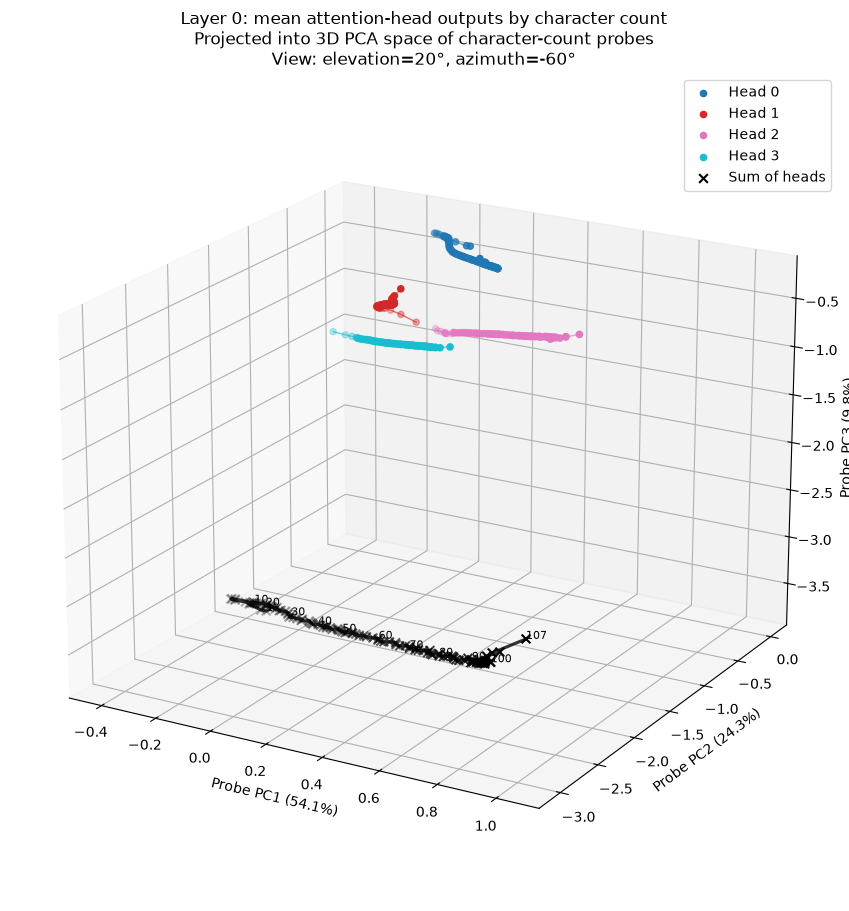

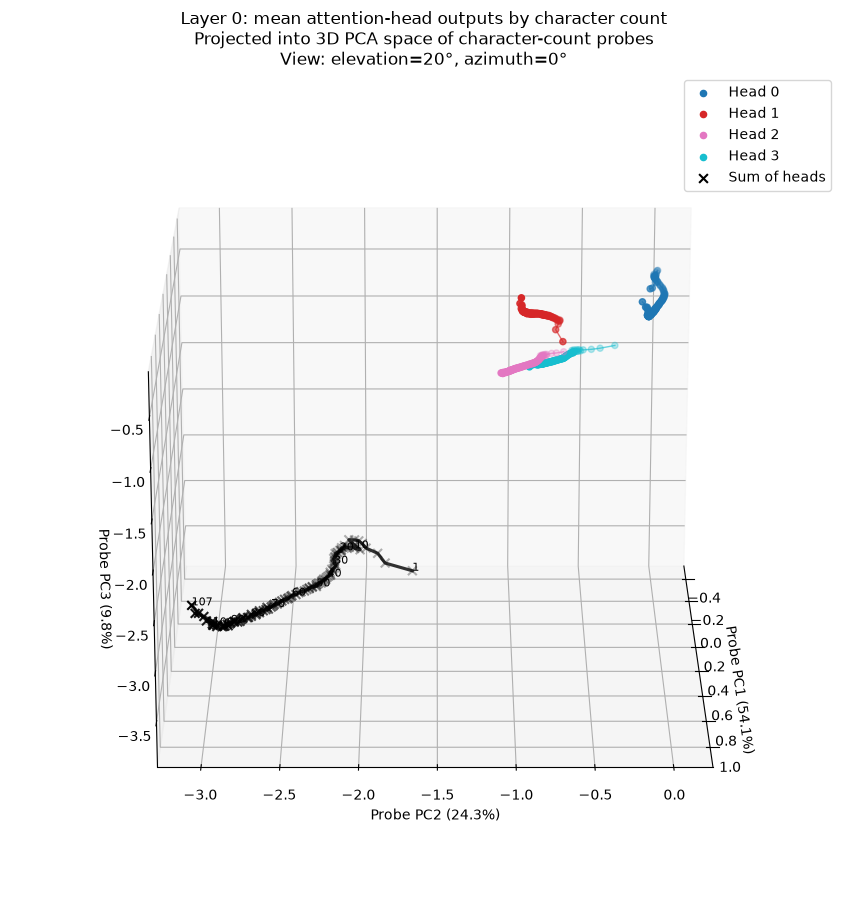

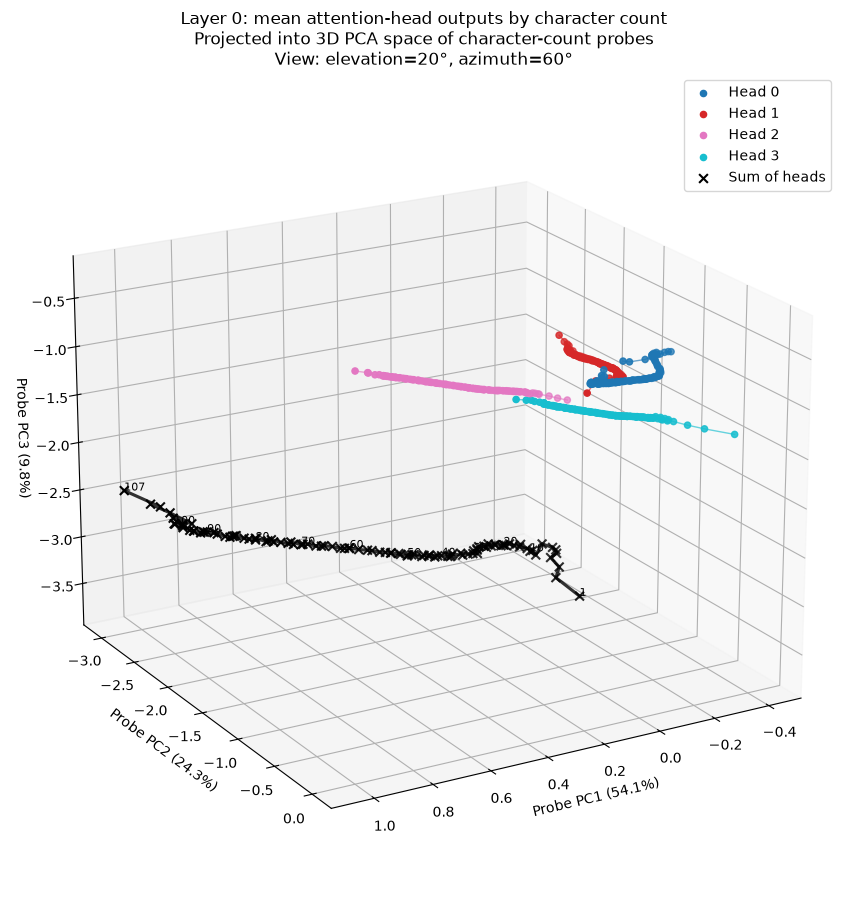

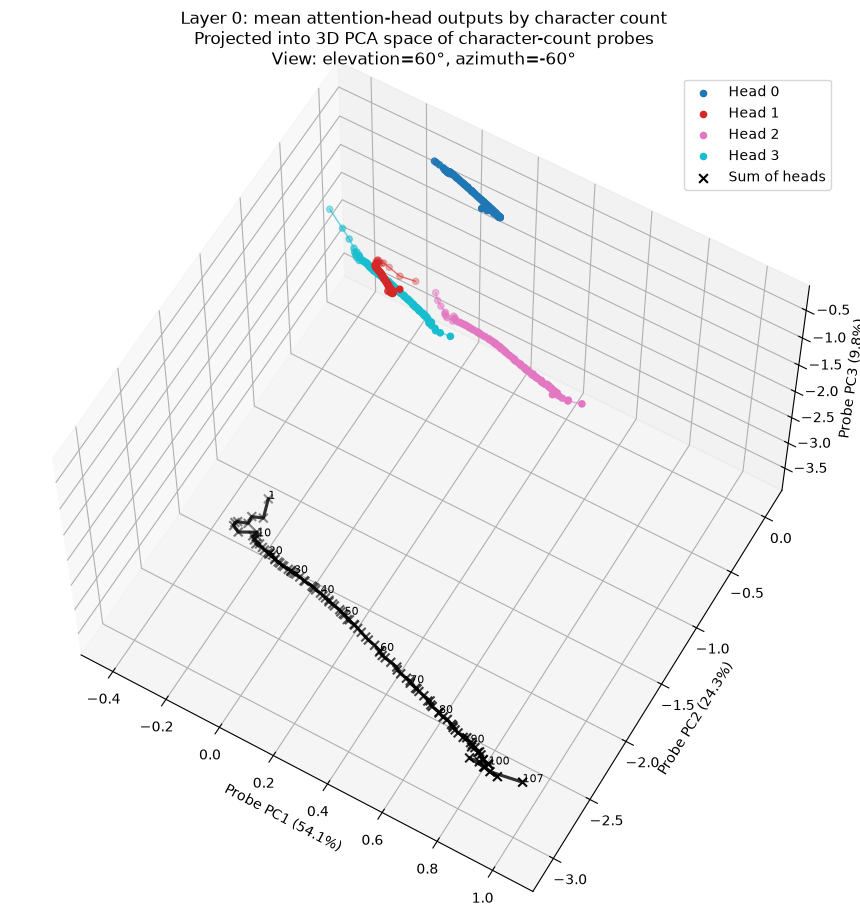

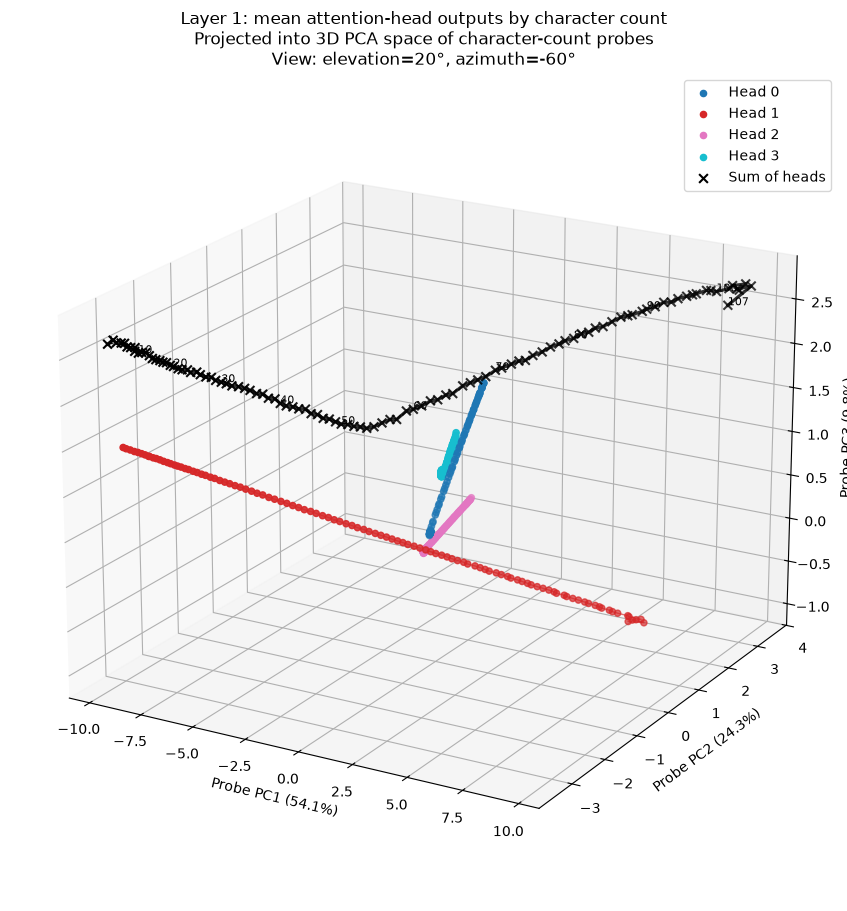

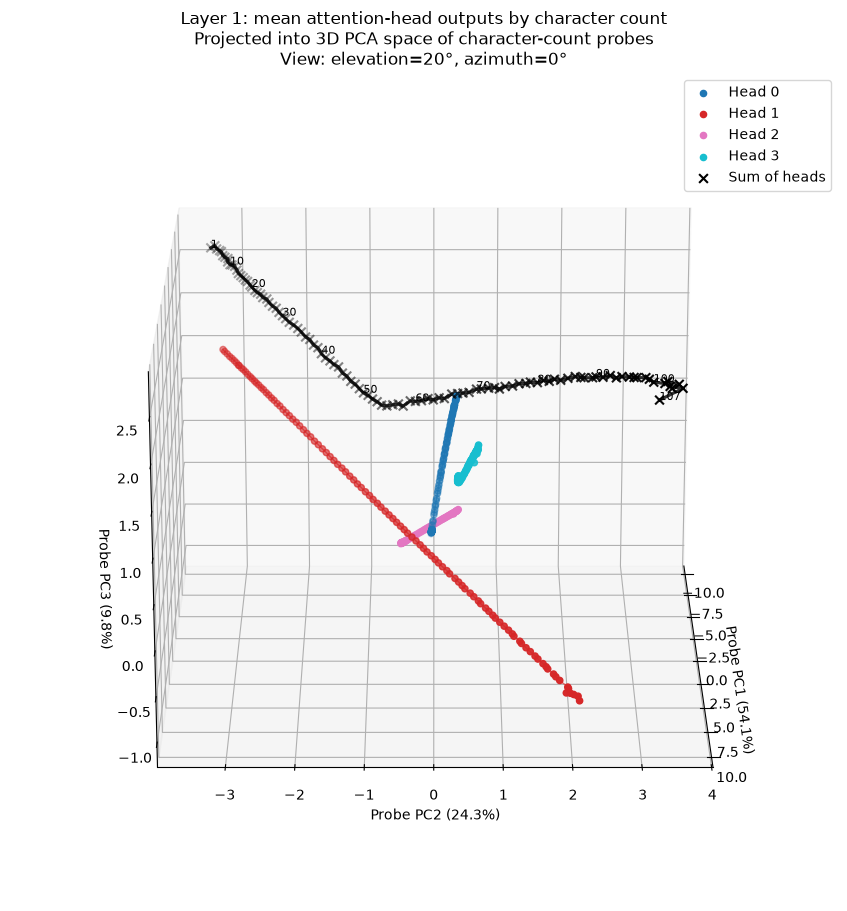

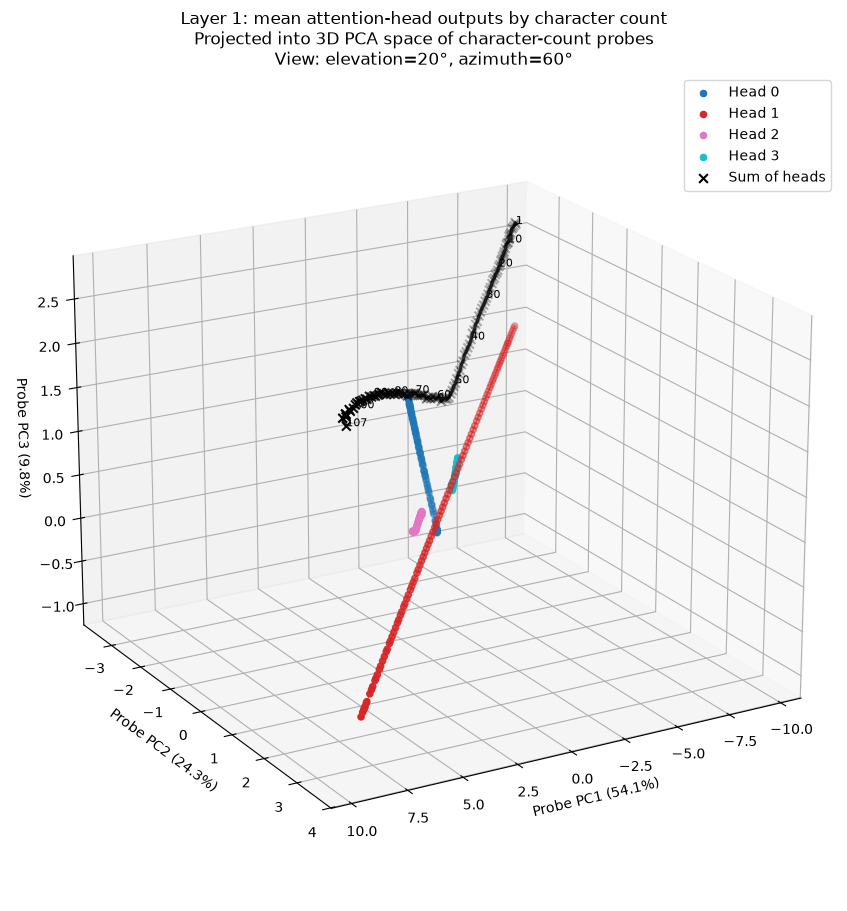

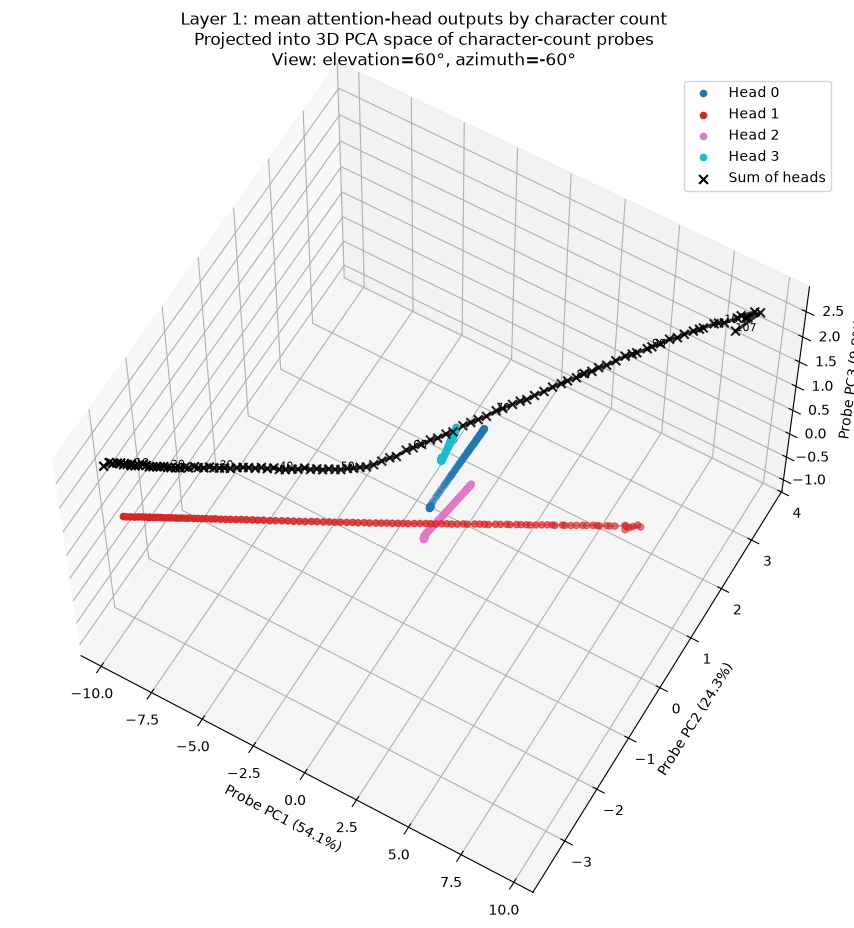

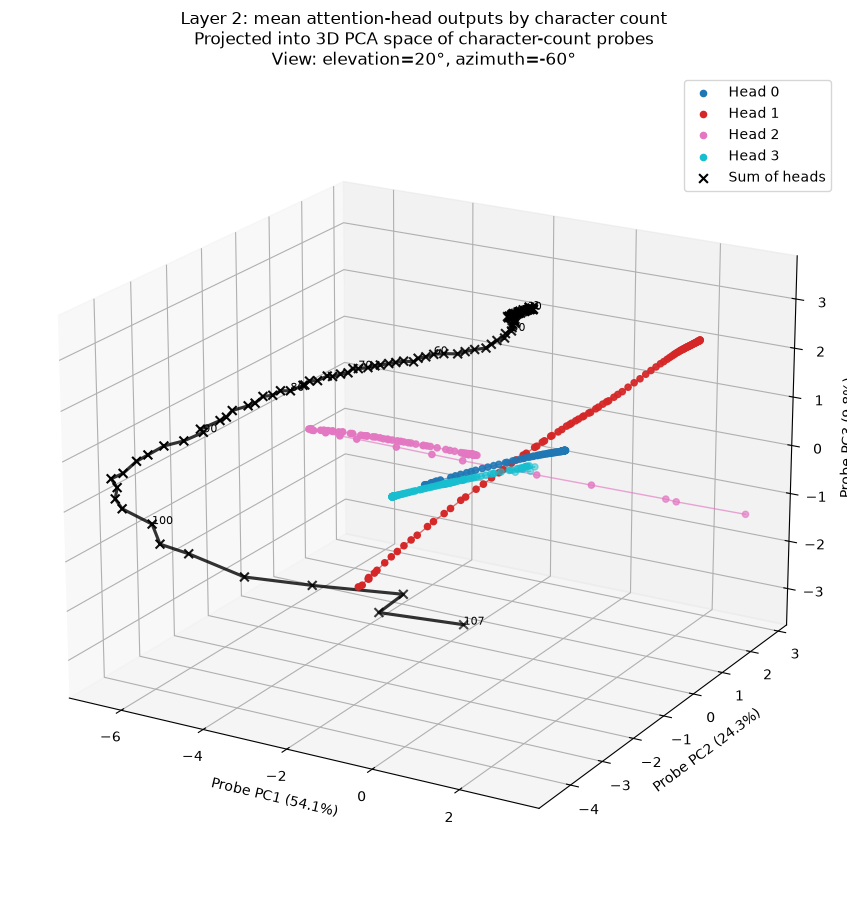

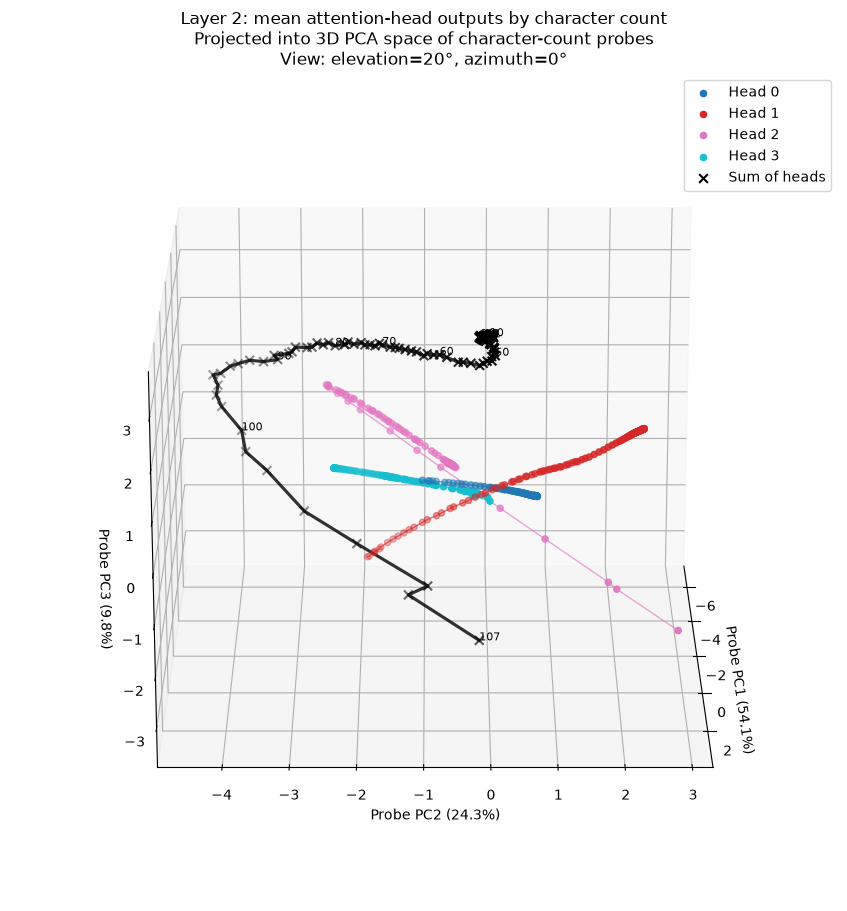

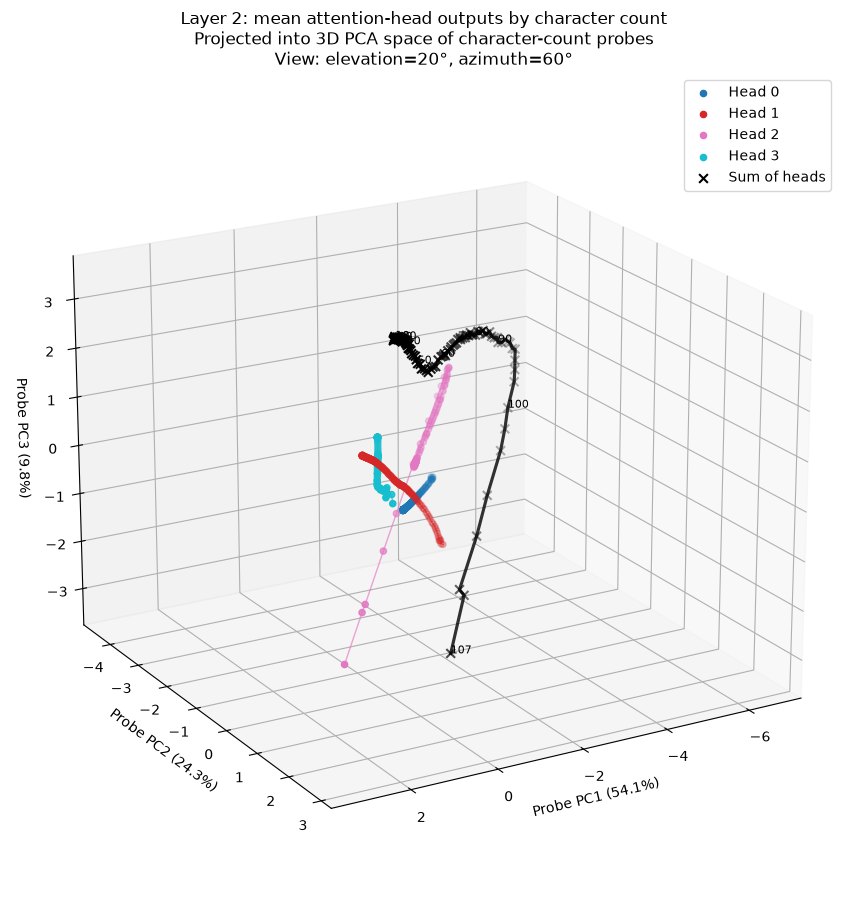

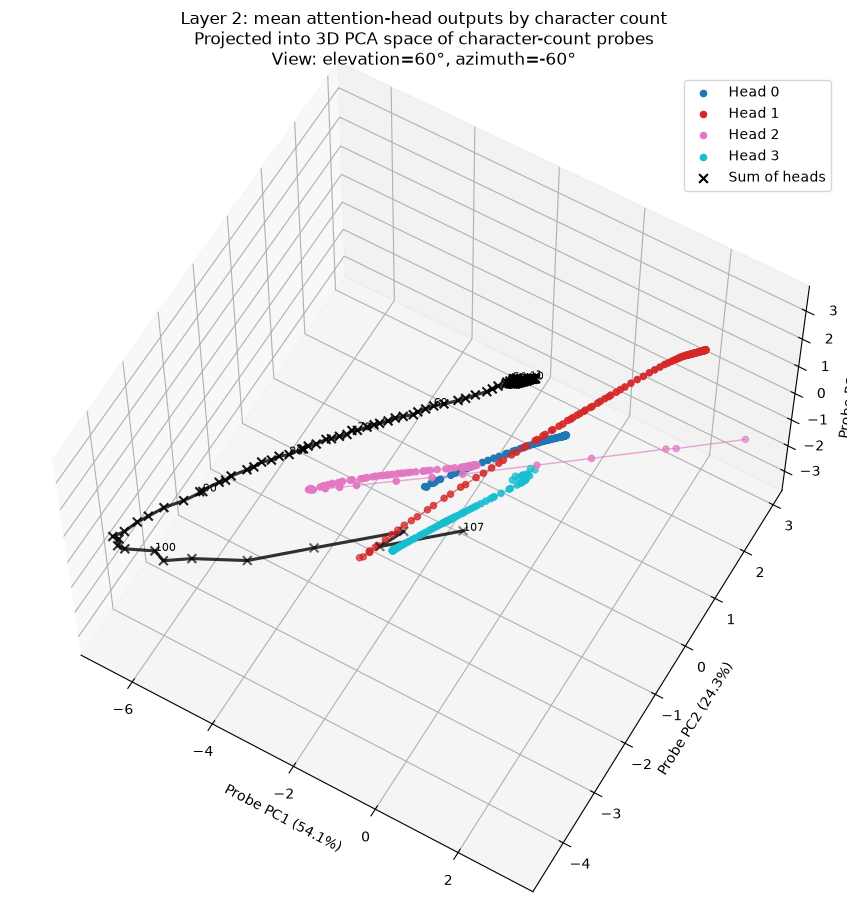

In [28]:
head_colors = plt.get_cmap("tab10")(np.linspace(0, 1, n_heads))
annotation_counts = set(
    np.r_[1, np.arange(ANNOTATE_EVERY, max_character_count + 1, ANNOTATE_EVERY), max_character_count]
)


def plot_layer_head_outputs(
    layer: int,
    *,
    view_angle: tuple[float, float] | None = None,
) -> None:
    if PCA_DIMENSIONS == 2:
        fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
    else:
        fig = plt.figure(figsize=(11, 9), constrained_layout=True)
        ax = fig.add_subplot(projection="3d")

    for head in range(n_heads):
        coordinates = projected_head_outputs[layer, :, head]
        if PCA_DIMENSIONS == 2:
            ax.plot(
                coordinates[:, 0], coordinates[:, 1],
                color=head_colors[head], alpha=0.65, linewidth=1.0,
            )
            ax.scatter(
                coordinates[:, 0], coordinates[:, 1],
                color=head_colors[head], s=20, label=f"Head {head}",
            )
        else:
            ax.plot(
                coordinates[:, 0], coordinates[:, 1], coordinates[:, 2],
                color=head_colors[head], alpha=0.65, linewidth=1.0,
            )
            ax.scatter(
                coordinates[:, 0], coordinates[:, 1], coordinates[:, 2],
                color=head_colors[head], s=20, label=f"Head {head}",
            )

    summed_coordinates = projected_summed_output[layer]
    if PCA_DIMENSIONS == 2:
        ax.plot(
            summed_coordinates[:, 0], summed_coordinates[:, 1],
            color="black", linewidth=2.25, alpha=0.8,
        )
        ax.scatter(
            summed_coordinates[:, 0], summed_coordinates[:, 1],
            color="black", marker="x", s=40, label="Sum of heads",
        )
        for count, coordinate in zip(CHARACTER_COUNTS, summed_coordinates):
            if count in annotation_counts:
                ax.annotate(str(count), coordinate[:2], fontsize=8)
    else:
        ax.plot(
            summed_coordinates[:, 0], summed_coordinates[:, 1], summed_coordinates[:, 2],
            color="black", linewidth=2.25, alpha=0.8,
        )
        ax.scatter(
            summed_coordinates[:, 0], summed_coordinates[:, 1], summed_coordinates[:, 2],
            color="black", marker="x", s=40, label="Sum of heads",
        )
        for count, coordinate in zip(CHARACTER_COUNTS, summed_coordinates):
            if count in annotation_counts:
                ax.text(*coordinate, str(count), fontsize=8)
        ax.set_zlabel(
            f"Probe PC3 ({probe_pca.explained_variance_ratio_[2]:.1%})"
        )
        if view_angle is None:
            raise ValueError("A view_angle is required for a 3D plot.")
        elevation, azimuth = view_angle
        ax.view_init(elev=elevation, azim=azimuth)

    ax.set_xlabel(f"Probe PC1 ({probe_pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"Probe PC2 ({probe_pca.explained_variance_ratio_[1]:.1%})")
    view_description = (
        ""
        if view_angle is None
        else f"\nView: elevation={view_angle[0]}°, azimuth={view_angle[1]}°"
    )
    ax.set_title(
        f"Layer {layer}: mean attention-head outputs by character count\n"
        f"Projected into {PCA_DIMENSIONS}D PCA space of character-count probes"
        f"{view_description}"
    )
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    plt.show()


for layer in range(n_layers):
    if PCA_DIMENSIONS == 2:
        plot_layer_head_outputs(layer)
    else:
        for view_angle in THREE_D_VIEW_ANGLES:
            plot_layer_head_outputs(layer, view_angle=view_angle)


## Freely rotatable 3D views

Run this section after the static plots when `PCA_DIMENSIONS == 3`. It switches Matplotlib to the installed widget backend and creates one interactive figure per layer. Drag inside a figure to rotate it; use the toolbar to pan, zoom, or reset the view.

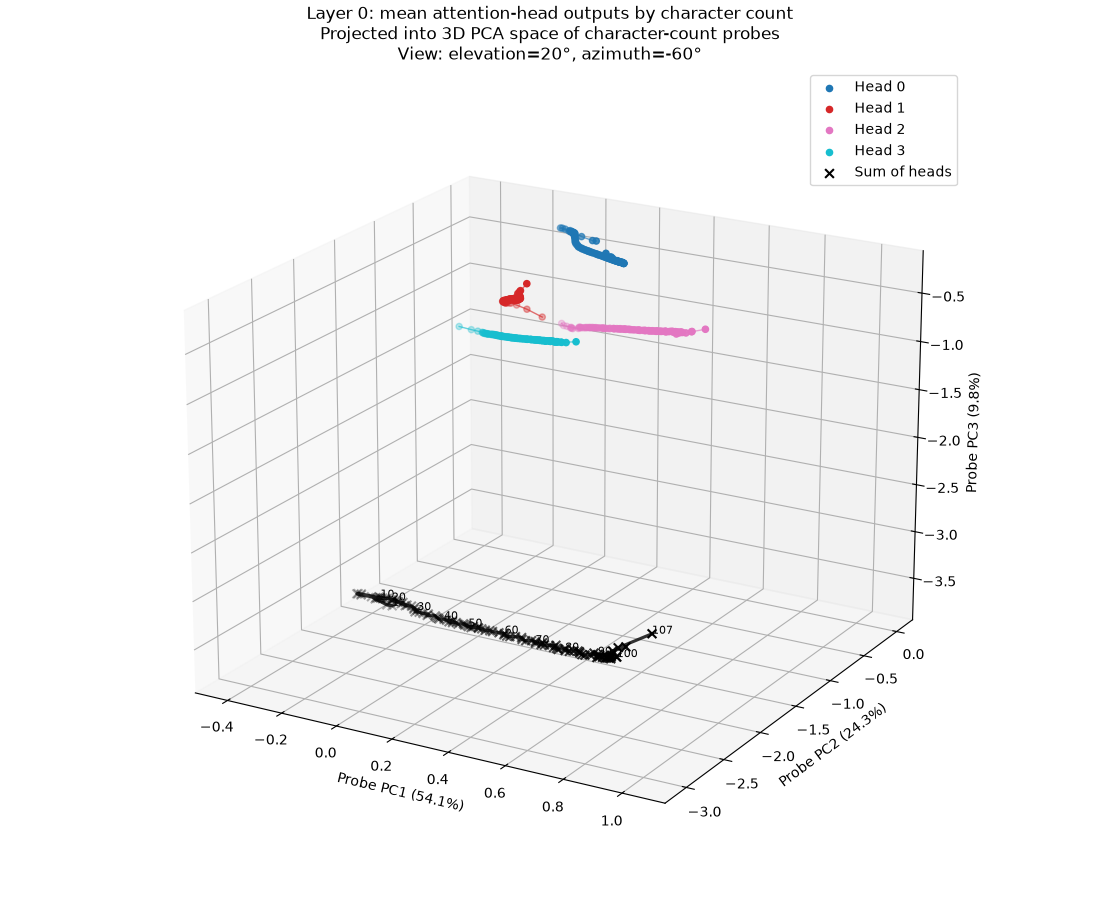

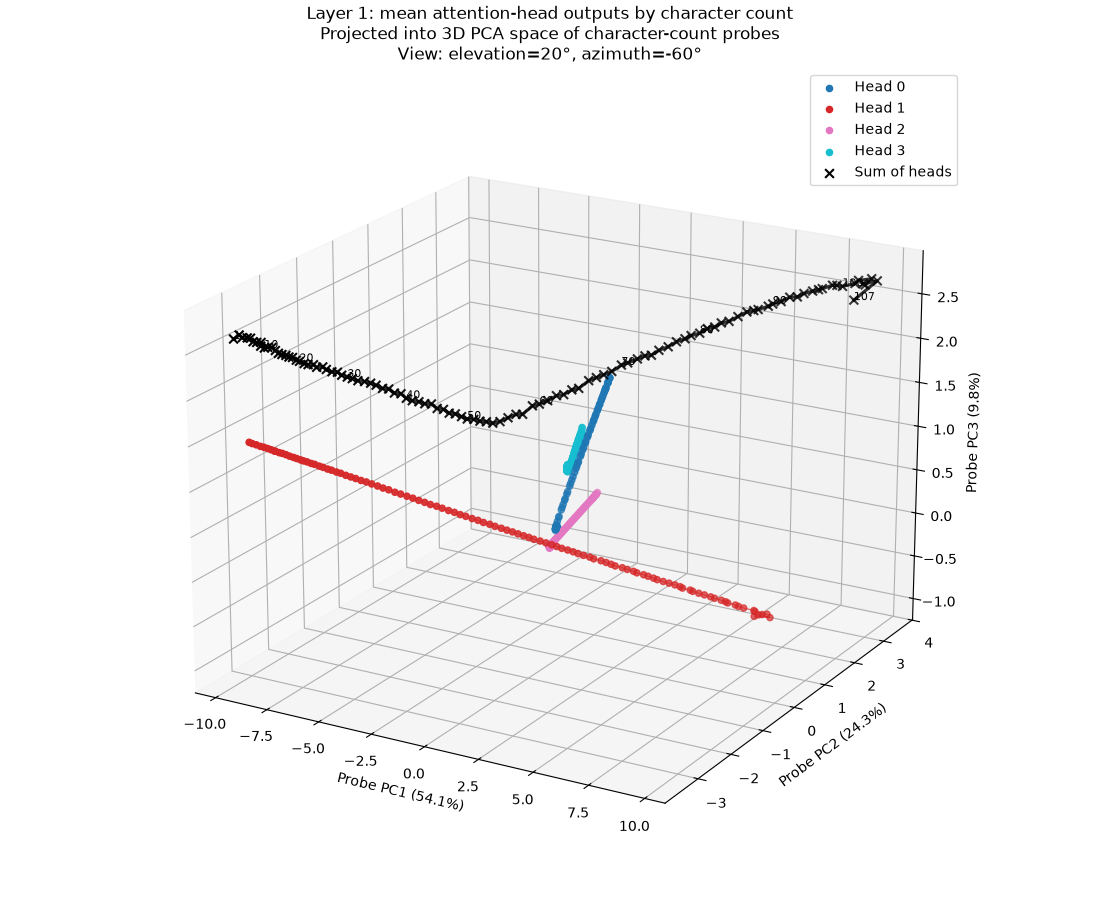

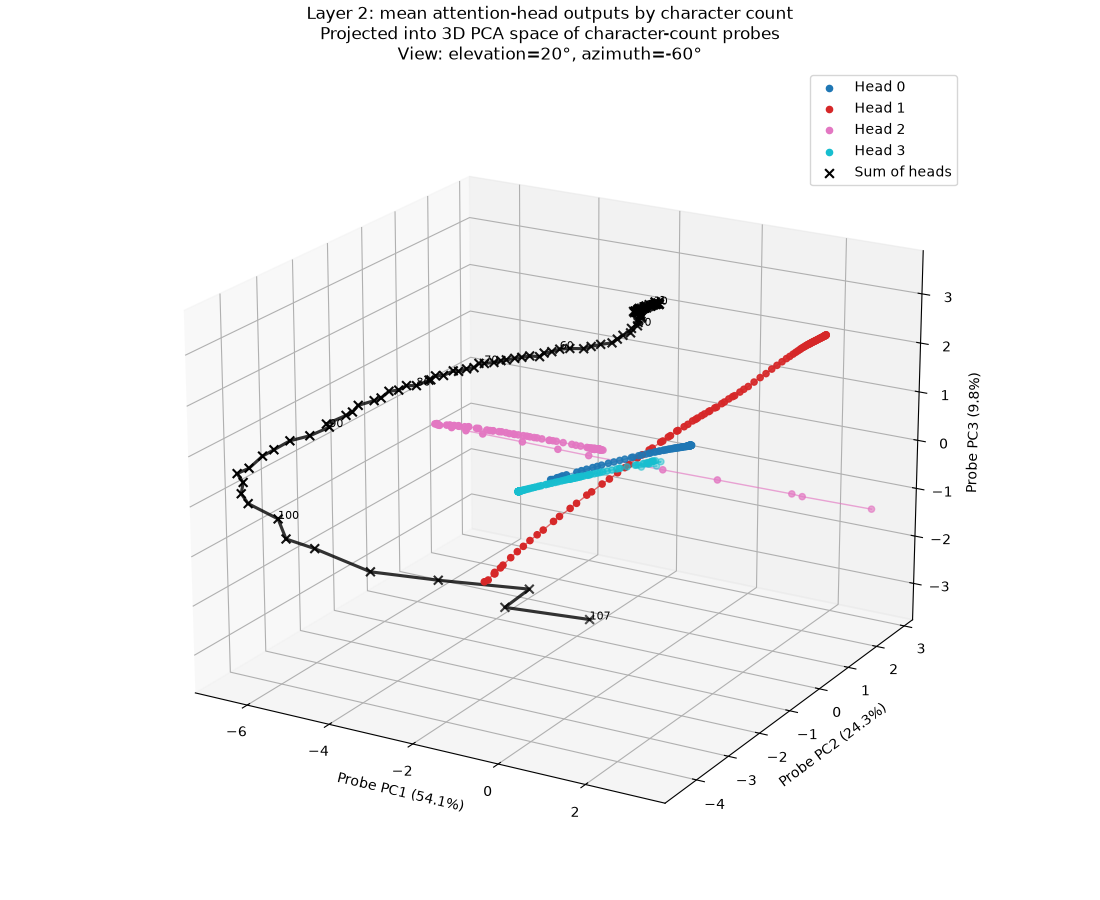

In [ ]:
%matplotlib widget

if PCA_DIMENSIONS != 3:
    print("Set PCA_DIMENSIONS = 3 and rerun the notebook to use interactive 3D views.")
else:
    initial_view = THREE_D_VIEW_ANGLES[0]
    for layer in range(n_layers):
        plot_layer_head_outputs(layer, view_angle=initial_view)
